# Fase 06 -- Comparación, selección y pronóstico final

**¿Qué hace este cuaderno?** Junta los 32 modelos por serie evaluados en las fases 02 a 05
(baselines, ML, DL, Prophet/hibrido/AutoML/fundación) en un solo tablero, marca los modelos
cuyo puntaje de validación es optimista porque se usó para elegir sus propios hiperparámetros
o miembros (contaminación de validación), aplica la regla de selección acordada (menor MAE de
validación entre los modelos no contaminados, sin desempate por parsimonia), confirma qué tan
estable es ese ranking cuando se mira la ventana de test, y por último reentrena el modelo
elegido -- junto con el peor, el SARIMA de TP1 y Chronos -- sobre todos los datos limpios
disponibles para pronosticar las próximas 48 horas con intervalos de predicción.

In [1]:
import sys
import warnings
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from tsa_final import data as d
from tsa_final import evaluation as ev
from tsa_final import selection as sel

RESULTS_DIR = Path.cwd().parent / "results"
FIGURES_DIR = Path.cwd().parent / "informe" / "figuras"

SERIES_NAMES = sel.SERIES_NAMES
SERIES_LABELS = {"alb": "ALB (RequestCount)", "store_service": "store_service (RequestCountPerTarget)"}

FAMILY_COLORS = {
    "naive": "#999999",
    "SARIMA (TP1 refit)": "#1f77b4",
    "classical": "#17becf",
    "ML": "#2ca02c",
    "ML (direct)": "#98df8a",
    "DL": "#d62728",
    "Prophet": "#9467bd",
    "Hybrid": "#8c564b",
    "AutoML": "#e377c2",
    "Foundation": "#bcbd22",
    "Ensemble": "#ff7f0e",
}

Importing plotly failed. Interactive plots will not work.


Importing plotly failed. Interactive plots will not work.


## 1. Todos los modelos en un solo tablero (tarea 06.1)

Se concatenan `results/02_baselines.csv` a `results/05_hybrid.csv` (32 modelos por serie, val +
test) y se agregan columnas de ranking (`val_rank`/`test_rank`, 1 = mejor) y de contaminación de
validación (ver siguiente sección). El resultado completo se guarda en
`results/06_all_models.csv` para el informe.

In [2]:
pool = sel.load_pool()
pool = sel.add_contamination_flags(pool)
pool = sel.add_rank_columns(pool)
pool.to_csv(RESULTS_DIR / "06_all_models.csv", index=False)
print(f"Guardadas {len(pool)} filas ({pool['model'].nunique()} nombres de modelo distintos) en {RESULTS_DIR / '06_all_models.csv'}")

for series_name in SERIES_NAMES:
    print(f"\n=== {series_name}: tabla de validación completa (orden por MAE) ===")
    val_cols = ["model", "family", "phase", "MAE", "MASE", "val_rank", "test_rank", "val_contaminated"]
    val_table = pool[(pool.series == series_name) & (pool.split == "val")][val_cols].sort_values("MAE")
    print(val_table.to_string(index=False))

Guardadas 128 filas (36 nombres de modelo distintos) en /home/juanma/development/university/AU-MCD/temporal-series-analysis/mcd-ua-tsa/tp-final/results/06_all_models.csv

=== alb: tabla de validación completa (orden por MAE) ===
                        model             family  phase           MAE     MASE  val_rank  test_rank  val_contaminated
               catboost_tuned                 ML      3  13994.361587 0.353497         1       <NA>              True
        ensemble_equal_weight           Ensemble      5  16006.287801 0.404318         2       <NA>              True
          random_forest_tuned                 ML      3  16478.207078 0.416238         3       <NA>              True
               lightgbm_tuned                 ML      3  16682.366221 0.421395         4       <NA>              True
                   auto_arima          classical      2  18807.501329 0.475076         5       <NA>             False
           seasonal_naive_m24              naive      2  19369.

## 2. Contaminación de validación: qué modelos no compiten limpio

Un modelo tiene **validación contaminada** cuando su puntaje de validación se midió sobre la
misma ventana que se usó para elegir sus propios hiperparámetros o sus propios miembros --
en ese caso el número de validación es optimista y no es comparable con el resto. Se
verificó contra el código y los documentos de estado de cada fase (no es una suposición):

- **`*_tuned` (fase 03)**: `tsa_final.ml_models.tune_hyperparameters` busca hiperparámetros con
  Optuna sobre un `TimeSeriesFold` con el corte exactamente en el borde train/val -- es decir,
  puntúa cada intento de búsqueda sobre la misma ventana de 48h que luego se usa para
  seleccionar modelos.
- **`stacking_top3` (fase 03)**: se construye con las 3 versiones `*_tuned` mejor rankeadas por
  MAE de validación (`notebooks/03_ml_models.ipynb`) -- hereda la contaminación de sus miembros
  y además los eligió por ese mismo MAE de validación.
- **`ensemble_equal_weight` (fase 05)**: promedia con peso igual al mejor modelo de las fases
  02/03/04 **por MAE de validación** (`status/05-hybrid-automl-foundation.md`) -- sus miembros
  se eligieron con la métrica que después se usa para puntuarlo.

`prophet_tuned` (fase 05) **no** se marca: su búsqueda de hiperparámetros usa una ventana de
168h separada e inmediatamente anterior a la ventana de selección, nunca la ventana de
selección misma (`status/05-hybrid-automl-foundation.md`, tarea 05.1) -- el mismo patrón
"leakage-safe" que la fase 04 usó para el *early stopping* de las redes.

In [3]:
for series_name in SERIES_NAMES:
    contaminated = pool[(pool.series == series_name) & (pool.split == "val") & (pool.val_contaminated)]
    print(f"\n=== {series_name}: modelos con validación contaminada (no elegibles) ===")
    print(contaminated[["model", "family", "MAE", "MASE", "contamination_reason"]].to_string(index=False))


=== alb: modelos con validación contaminada (no elegibles) ===
                model   family           MAE     MASE                                                                                                                                                                                                                                                     contamination_reason
       catboost_tuned       ML  13994.361587 0.353497 Hyperparameters tuned with Optuna (tsa_final.ml_models.tune_hyperparameters), scored on a TimeSeriesFold at the train/val boundary -- the same 48h window later used to rank and select models. Wins validation, then frequently loses on test (status/03-ml-models.md).
  random_forest_tuned       ML  16478.207078 0.416238 Hyperparameters tuned with Optuna (tsa_final.ml_models.tune_hyperparameters), scored on a TimeSeriesFold at the train/val boundary -- the same 48h window later used to rank and select models. Wins validation, then frequently loses on test (stat

## 3. Mejor modelo de cada familia (tarea 06.1)

Por cada familia (incluidas las contaminadas, marcadas), el modelo con menor MAE de validación.

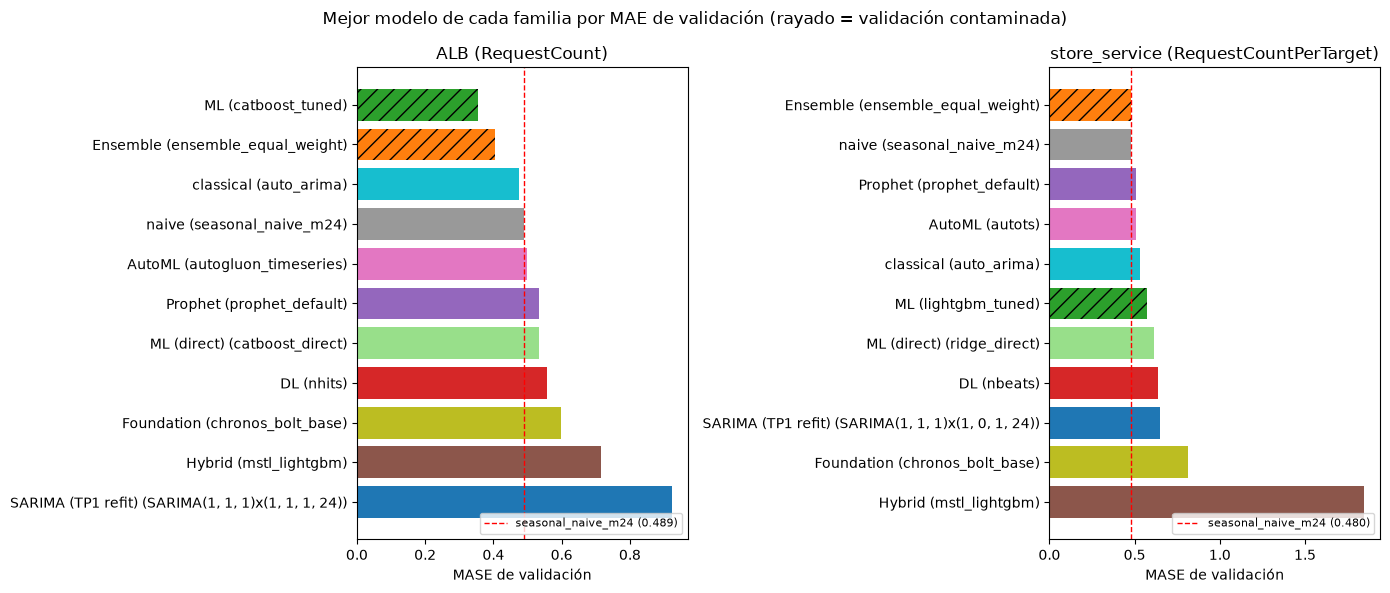

In [4]:
fig, axes = plt.subplots(1, len(SERIES_NAMES), figsize=(14, 6))
for ax, series_name in zip(axes, SERIES_NAMES):
    bpf = sel.best_per_family(pool, series_name).sort_values("MASE", ascending=False)
    colors = [FAMILY_COLORS.get(f, "#333333") for f in bpf["family"]]
    hatches = ["//" if c else "" for c in bpf["val_contaminated"]]
    bars = ax.barh(bpf["family"] + " (" + bpf["model"] + ")", bpf["MASE"], color=colors)
    for bar, hatch in zip(bars, hatches):
        bar.set_hatch(hatch)
    naive_mase = pool.loc[
        (pool.series == series_name) & (pool.split == "val") & (pool.model == "seasonal_naive_m24"), "MASE"
    ].iloc[0]
    ax.axvline(naive_mase, color="red", linestyle="--", linewidth=1, label=f"seasonal_naive_m24 ({naive_mase:.3f})")
    ax.set_xlabel("MASE de validación")
    ax.set_title(SERIES_LABELS[series_name])
    ax.legend(fontsize=8, loc="lower right")
plt.suptitle("Mejor modelo de cada familia por MAE de validación (rayado = validación contaminada)")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "06_best_per_family.png", dpi=200)
plt.show()

## 4. La regla de selección y el resultado (tareas 06.2, 06.4)

**Regla acordada con el usuario**: el modelo seleccionado por serie es el de **menor MAE de
validación entre los modelos elegibles** (no contaminados). No hay desempate por parsimonia --
se quiere el mejor desempeño, no el modelo más simple entre los cercanos. Las métricas de test
se reportan siempre pero nunca se usan para seleccionar.

También se identifica el **peor modelo elegible** (mayor MAE de validación, nunca un modelo
contaminado -- su número es optimista, no pesimista, así que no sería honesto llamarlo "el
peor") y se compara contra dos referencias: el **SARIMA de TP1 reajustado** ("fundacional" en
el vocabulario del usuario -- los modelos clásicos de TP1) y **Chronos-Bolt** (el "modelo de
fundación", *foundation model*, de la fase 05).

In [5]:
summary_rows = []
for series_name in SERIES_NAMES:
    res = sel.select_model(pool, series_name)
    ref = sel.tp1_and_foundation_reference(pool, series_name)
    tp1_row = ref[ref.family == "SARIMA (TP1 refit)"].iloc[0]
    chronos_row = ref[ref.family == "Foundation"].iloc[0]
    test_row = lambda model: pool[(pool.series == series_name) & (pool.split == "test") & (pool.model == model)].iloc[0]

    sel_test = test_row(res.selected["model"])
    naive_test = test_row("seasonal_naive_m24")
    tp1_test = test_row(tp1_row["model"])

    print(f"\n=== {series_name} ===")
    print(f"Seleccionado : {res.selected['model']:<24} val MAE={res.selected['MAE']:>12,.1f}  val MASE={res.selected['MASE']:.3f}  test MASE={sel_test['MASE']:.3f}")
    print(f"Subcampeón   : {res.runner_up['model']:<24} val MAE={res.runner_up['MAE']:>12,.1f}  val MASE={res.runner_up['MASE']:.3f}")
    print(f"Peor elegible: {res.worst['model']:<24} val MAE={res.worst['MAE']:>12,.1f}  val MASE={res.worst['MASE']:.3f}")
    print(f"TP1 fundacional ({tp1_row['model']}): val MASE={tp1_row['MASE']:.3f}  test MASE={tp1_test['MASE']:.3f}")
    print(f"Foundation model (chronos_bolt_base): val MASE={chronos_row['MASE']:.3f}  test MASE={test_row('chronos_bolt_base')['MASE']:.3f}")

    print("Mejora del seleccionado sobre TP1 SARIMA -- validación: "
          f"{sel.pct_improvement(tp1_row['MAE'], res.selected['MAE']):+.1f}%   test: "
          f"{sel.pct_improvement(tp1_test['MAE'], sel_test['MAE']):+.1f}%")
    print("Mejora del seleccionado sobre seasonal_naive_m24 -- validación: "
          f"{sel.pct_improvement(pool[(pool.series == series_name) & (pool.split == 'val') & (pool.model == 'seasonal_naive_m24')].iloc[0]['MAE'], res.selected['MAE']):+.1f}%   test: "
          f"{sel.pct_improvement(naive_test['MAE'], sel_test['MAE']):+.1f}%")

    summary_rows.append({
        "series": series_name,
        "selected": res.selected["model"],
        "runner_up": res.runner_up["model"],
        "worst": res.worst["model"],
        "tp1_foundational": tp1_row["model"],
        "foundation_model": "chronos_bolt_base",
    })

selection_summary = pd.DataFrame(summary_rows)
selection_summary


=== alb ===
Seleccionado : auto_arima               val MAE=    18,807.5  val MASE=0.475  test MASE=2.058
Subcampeón   : seasonal_naive_m24       val MAE=    19,369.0  val MASE=0.489
Peor elegible: average                  val MAE=   149,950.9  val MASE=3.788
TP1 fundacional (SARIMA(1, 1, 1)x(1, 1, 1, 24)): val MASE=0.923  test MASE=1.526
Foundation model (chronos_bolt_base): val MASE=0.598  test MASE=2.007
Mejora del seleccionado sobre TP1 SARIMA -- validación: +48.5%   test: -34.9%
Mejora del seleccionado sobre seasonal_naive_m24 -- validación: +2.9%   test: -3.4%

=== store_service ===
Seleccionado : seasonal_naive_m24       val MAE=     2,281.9  val MASE=0.480  test MASE=1.443
Subcampeón   : prophet_default          val MAE=     2,405.9  val MASE=0.506
Peor elegible: drift                    val MAE=    17,022.7  val MASE=3.582
TP1 fundacional (SARIMA(1, 1, 1)x(1, 0, 1, 24)): val MASE=0.647  test MASE=1.426
Foundation model (chronos_bolt_base): val MASE=0.816  test MASE=1.673
Mejo

,series,selected,runner_up,worst,tp1_foundational,foundation_model
0,alb,auto_arima,seasonal_naive_m24,average,"SARIMA(1, 1, 1)x(1, 1, 1, 24)",chronos_bolt_base
1,store_service,seasonal_naive_m24,prophet_default,drift,"SARIMA(1, 1, 1)x(1, 0, 1, 24)",chronos_bolt_base


## 5. ¿Se sostiene el ranking en test? Correlación de Spearman (tarea 06.3)

Se calcula la correlación de rangos de Spearman entre el MAE de validación y el MAE de test,
para los 32 modelos y también restringida a los elegibles. Un valor bajo confirma lo que las
fases 02 a 05 ya venían mostrando: la ventana de validación de 48h es una sola muestra, chica y
ruidosa (no *backtesting* de múltiples ventanas) -- eso es una **limitación**, y la razón por la
que la regla de selección nunca usa test, no al revés.


=== alb ===  Spearman (32 modelos): 0.237 (p=0.192)   Spearman (elegibles): 0.346 (p=0.077)
Mayor divergencia de ranking val vs. test:
                        model  val_rank  test_rank  rank_diff
          random_forest_tuned       3.0       28.0         25
SARIMA(1, 1, 1)x(1, 1, 1, 24)      23.0        1.0        -22
                       nbeats      24.0        4.0        -20
                        ridge      22.0        3.0        -19
               lightgbm_tuned       4.0       22.0         18

=== store_service ===  Spearman (32 modelos): 0.654 (p=0.000)   Spearman (elegibles): 0.692 (p=0.000)
Mayor divergencia de ranking val vs. test:
                model  val_rank  test_rank  rank_diff
        random_forest      26.0        5.0        -21
         ridge_direct       8.0       23.0         15
ensemble_equal_weight       1.0       15.0         14
       lightgbm_tuned       7.0       21.0         14
        neuralprophet      14.0        1.0        -13


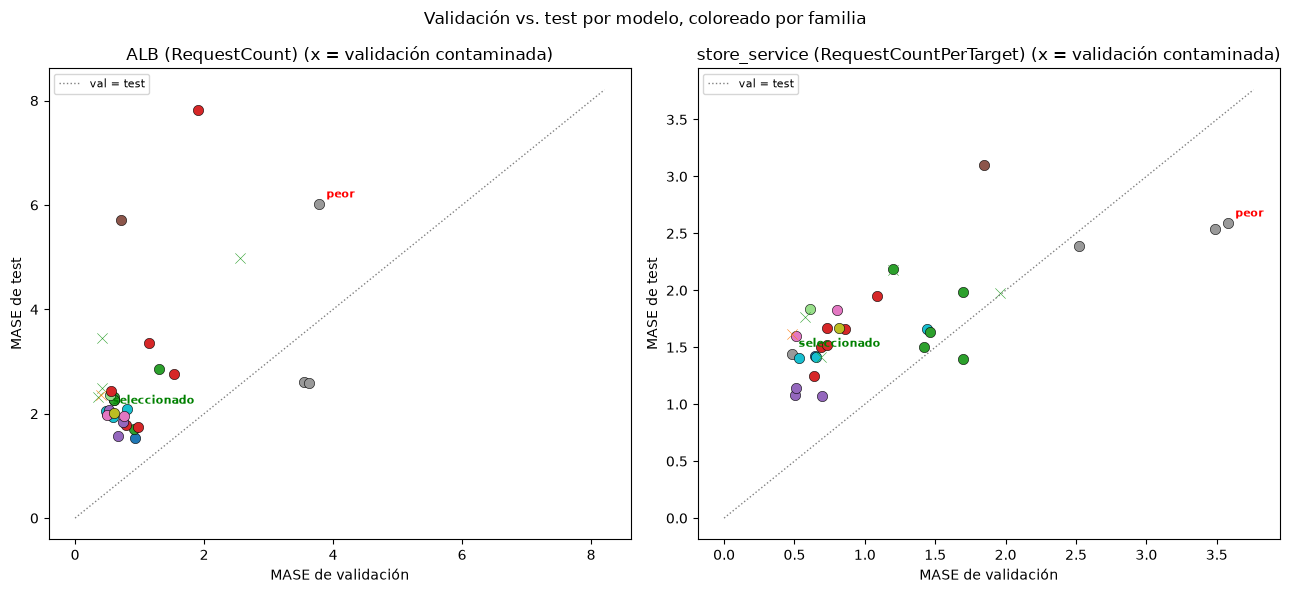

In [6]:
fig, axes = plt.subplots(1, len(SERIES_NAMES), figsize=(13, 6))
for ax, series_name in zip(axes, SERIES_NAMES):
    cons_all = sel.val_test_consistency(pool, series_name, eligible_only=False)
    cons_elig = sel.val_test_consistency(pool, series_name, eligible_only=True)
    print(f"\n=== {series_name} ===  Spearman (32 modelos): {cons_all.rho:.3f} (p={cons_all.p_value:.3f})   "
          f"Spearman (elegibles): {cons_elig.rho:.3f} (p={cons_elig.p_value:.3f})")
    print("Mayor divergencia de ranking val vs. test:")
    print(cons_all.table.head(5)[["model", "val_rank", "test_rank", "rank_diff"]].to_string(index=False))

    val_sub = pool[(pool.series == series_name) & (pool.split == "val")]
    test_sub = pool[(pool.series == series_name) & (pool.split == "test")]
    merged = val_sub.merge(test_sub, on="model", suffixes=("_val", "_test"))
    colors = [FAMILY_COLORS.get(f, "#333333") for f in merged["family_val"]]
    markers = ["x" if c else "o" for c in merged["val_contaminated_val"]]
    for _, row in merged.iterrows():
        marker = "x" if row["val_contaminated_val"] else "o"
        ax.scatter(row["MASE_val"], row["MASE_test"], color=FAMILY_COLORS.get(row["family_val"], "#333333"),
                   marker=marker, s=55, edgecolors="black", linewidths=0.4)
    res = sel.select_model(pool, series_name)
    for label, model_name, color in (("seleccionado", res.selected["model"], "green"), ("peor", res.worst["model"], "red")):
        row = merged[merged.model == model_name].iloc[0]
        ax.annotate(label, (row["MASE_val"], row["MASE_test"]), textcoords="offset points", xytext=(5, 5),
                    fontsize=8, color=color, fontweight="bold")
    lim = max(merged["MASE_val"].max(), merged["MASE_test"].max()) * 1.05
    ax.plot([0, lim], [0, lim], color="gray", linestyle=":", linewidth=1, label="val = test")
    ax.set_xlabel("MASE de validación")
    ax.set_ylabel("MASE de test")
    ax.set_title(f"{SERIES_LABELS[series_name]} (x = validación contaminada)")
    ax.legend(fontsize=8)
plt.suptitle("Validación vs. test por modelo, coloreado por familia")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "06_val_vs_test_scatter.png", dpi=200)
plt.show()

## 6. Análisis de sensibilidad (informativo -- **no** es la regla de selección)

¿Quién ganaría bajo otro criterio? Se muestra a modo de discusión, nunca para reemplazar la
regla adoptada en la sección 4:

(a) la regla adoptada (MAE de validación, elegibles); (b) MAE de validación incluyendo los
modelos contaminados; (c) MAE de test como si fuera un oráculo (imposible en la práctica: el
test no se conoce al momento de elegir un modelo).

In [7]:
for series_name in SERIES_NAMES:
    print(f"\n=== {series_name} ===")
    print(sel.sensitivity_table(pool, series_name).to_string(index=False))


=== alb ===
                              criterion                        winner          MAE
       adopted rule (eligible, val MAE)                    auto_arima 18807.501329
including contaminated scores (val MAE)                catboost_tuned 13994.361587
      test MAE oracle (discussion only) SARIMA(1, 1, 1)x(1, 1, 1, 24) 60429.073334

=== store_service ===
                              criterion                winner         MAE
       adopted rule (eligible, val MAE)    seasonal_naive_m24 2281.852431
including contaminated scores (val MAE) ensemble_equal_weight 2281.636637
      test MAE oracle (discussion only)         neuralprophet 5090.391319


## 7. Comparación en la ventana de test: seleccionado vs. peor vs. TP1 vs. Chronos (tarea 06.6)

Se reentrena cada uno de los cuatro roles (seleccionado, peor, SARIMA fundacional de TP1,
Chronos) sobre train+val y se pronostica la ventana de test real (105h) -- reutilizando, sin
modificar, las mismas funciones `fit` de `tsa_final.baselines`/`tsa_final.hybrid_models` que ya
se usaron en las fases 02 y 05. Es la misma comparación que ya está en `results/06_all_models.csv`
como métrica; aquí se ve como pronóstico contra el dato real.

Loading weights:   0%|          | 0/269 [00:00<?, ?it/s]

Loading weights:  80%|███████▉  | 215/269 [00:00<00:00, 2148.67it/s]

Loading weights: 100%|██████████| 269/269 [00:00<00:00, 2050.69it/s]

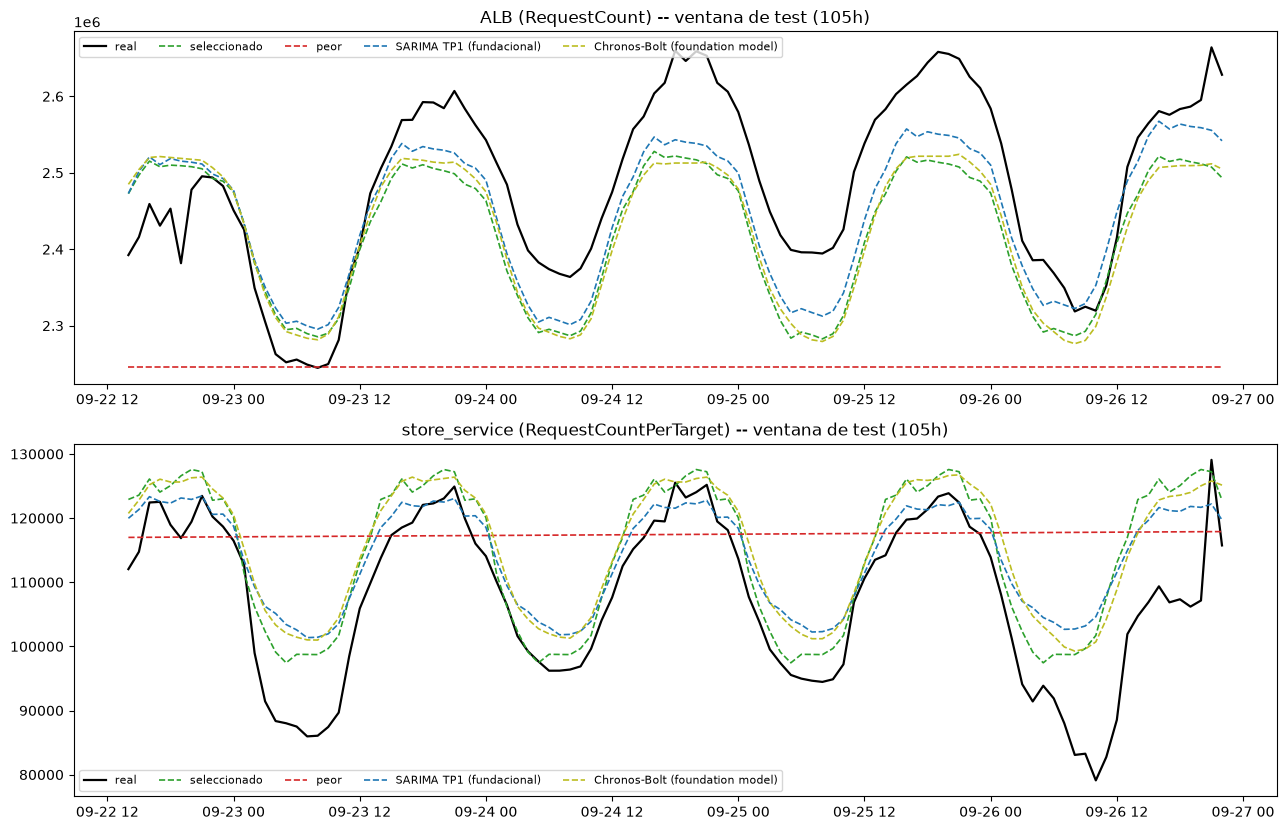

In [8]:
fig, axes = plt.subplots(len(SERIES_NAMES), 1, figsize=(13, 4.2 * len(SERIES_NAMES)))
role_labels = {
    "selected": "seleccionado",
    "worst": "peor",
    "tp1_foundational": "SARIMA TP1 (fundacional)",
    "foundation_model": "Chronos-Bolt (foundation model)",
}
role_colors = {"selected": "#2ca02c", "worst": "#d62728", "tp1_foundational": "#1f77b4", "foundation_model": "#bcbd22"}

overlay_cache = {}
for ax, series_name in zip(axes, SERIES_NAMES):
    forecasts, test = sel.test_overlay_forecasts(series_name)
    overlay_cache[series_name] = (forecasts, test)
    ax.plot(test.index, test.to_numpy(), color="black", linewidth=1.6, label="real")
    for role, arr in forecasts.items():
        ax.plot(test.index, arr, color=role_colors[role], linestyle="--", linewidth=1.2, label=role_labels[role])
    ax.set_title(f"{SERIES_LABELS[series_name]} -- ventana de test (105h)")
    ax.legend(fontsize=8, ncol=5)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "06_test_overlay_forecast.png", dpi=200)
plt.show()

## 8. Pronóstico final a 48 horas (tarea 06.5)

Cada rol (seleccionado, peor, SARIMA fundacional de TP1, Chronos) se reentrena sobre **todos los
datos limpios disponibles** (`data.load_clean`, hasta 2026-09-26 22:00 UTC) y pronostica las 48h
siguientes (2026-09-26 23:00 -> 2026-09-28 22:00 UTC). Intervalos de predicción:

- **SARIMA (TP1 y auto_arima)**: intervalos nativos de `statsmodels`/`statsforecast`
  (`get_forecast().conf_int()` / `level=[80, 95]`).
- **Chronos-Bolt**: intervalo nativo de 80% (`predict_df(quantile_levels=[0.1, 0.9])`). El 95%
  se deja en blanco a propósito: Chronos-Bolt se entrenó solo con niveles de cuantil entre 0.1 y
  0.9 (advertencia de la propia librería, verificada); pedirle 0.025/0.975 los recorta al mismo
  0.1/0.9, lo que haría parecer que el intervalo de 95% es igual al de 80% -- fabricar ese
  número sería menos honesto que dejarlo vacío.
- **Modelos sin intervalo propio** (`seasonal_naive_m24`, `average`, `drift`): intervalo
  empírico simple. Se toman los residuos (real - pronóstico) de la ventana de validación de 48h
  (n=48, la misma ventana ruidosa que las fases 02-05 ya documentaron) y se usan sus percentiles
  empíricos como desplazamientos constantes sobre el pronóstico final -- no varían con el paso
  del horizonte. Es una aproximación honesta y simple del error, no un intervalo calibrado.

In [9]:
final_forecast = sel.build_final_forecast_table()
final_forecast.to_csv(RESULTS_DIR / "06_final_forecast.csv", index=False)
print(f"Guardadas {len(final_forecast)} filas en {RESULTS_DIR / '06_final_forecast.csv'}")
print(final_forecast.groupby(["series", "role", "model"]).size())

Guardadas 384 filas en /home/juanma/development/university/AU-MCD/temporal-series-analysis/mcd-ua-tsa/tp-final/results/06_final_forecast.csv
series         role              model                   
alb            foundation_model  chronos_bolt_base           48
               selected          auto_arima                  48
               tp1_foundational  SARIMA(1,1,1)x(1,1,1,24)    48
               worst             average                     48
store_service  foundation_model  chronos_bolt_base           48
               selected          seasonal_naive_m24          48
               tp1_foundational  SARIMA(1,1,1)x(1,0,1,24)    48
               worst             drift                       48
dtype: int64


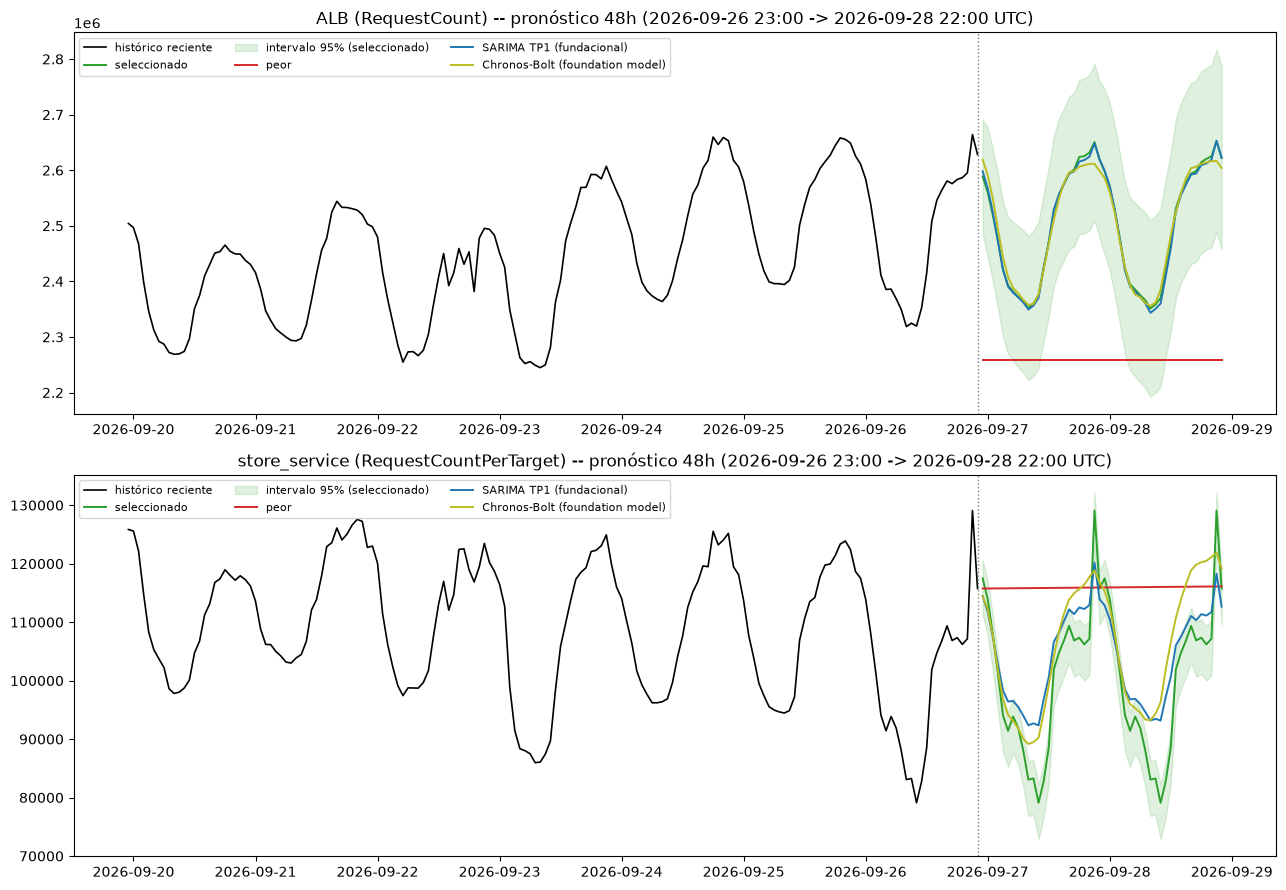

In [10]:
fig, axes = plt.subplots(len(SERIES_NAMES), 1, figsize=(13, 4.5 * len(SERIES_NAMES)))
history_hours = 7 * 24
for ax, series_name in zip(axes, SERIES_NAMES):
    series = d.load_clean(series_name)
    history = series.iloc[-history_hours:]
    ax.plot(history.index, history.to_numpy(), color="black", linewidth=1.2, label="histórico reciente")

    sub = final_forecast[final_forecast.series == series_name]
    for role in ("selected", "worst", "tp1_foundational", "foundation_model"):
        role_df = sub[sub.role == role].sort_values("timestamp")
        ax.plot(role_df.timestamp, role_df.yhat, color=role_colors[role], linewidth=1.4, label=role_labels[role])
        if role == "selected":
            has_95 = role_df["lower_95"].notna().all()
            lower_col, upper_col = ("lower_95", "upper_95") if has_95 else ("lower_80", "upper_80")
            ax.fill_between(role_df.timestamp, role_df[lower_col], role_df[upper_col],
                             color=role_colors[role], alpha=0.15,
                             label=f"intervalo {'95' if has_95 else '80'}% (seleccionado)")
    ax.axvline(history.index[-1], color="gray", linestyle=":", linewidth=1)
    ax.set_title(f"{SERIES_LABELS[series_name]} -- pronóstico 48h (2026-09-26 23:00 -> 2026-09-28 22:00 UTC)")
    ax.legend(fontsize=8, ncol=3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "06_final_forecast.png", dpi=200)
plt.show()

## 9. Conclusiones de la fase

In [11]:
print("Resumen de la fase 06:\n")
for series_name in SERIES_NAMES:
    res = sel.select_model(pool, series_name)
    ref = sel.tp1_and_foundation_reference(pool, series_name)
    tp1_row = ref[ref.family == "SARIMA (TP1 refit)"].iloc[0]
    print(f"{series_name}: seleccionado={res.selected['model']} (val MASE {res.selected['MASE']:.3f}), "
          f"peor={res.worst['model']} (val MASE {res.worst['MASE']:.3f}), "
          f"TP1 SARIMA val MASE {tp1_row['MASE']:.3f}")

Resumen de la fase 06:

alb: seleccionado=auto_arima (val MASE 0.475), peor=average (val MASE 3.788), TP1 SARIMA val MASE 0.923
store_service: seleccionado=seasonal_naive_m24 (val MASE 0.480), peor=drift (val MASE 3.582), TP1 SARIMA val MASE 0.647


- **ALB**: el modelo seleccionado es `auto_arima` (MAE de validación 18,807.5, MASE 0.475),
  apenas por debajo de `seasonal_naive_m24` (el subcampeón, MASE 0.489) y de
  `autogluon_timeseries` (tercero, MASE 0.499) -- una diferencia pequeña, no una goleada. Le
  gana al SARIMA fundacional de TP1 por un 48.5% en validación, pero en test la relación se
  invierte: `auto_arima` pierde contra el SARIMA de TP1 (-34.9%) y contra la naive estacional
  (-3.4%). Esto repite exactamente el patrón que documentaron las fases 02 a 05: la ventana de
  validación de 48h es una sola muestra ruidosa (Spearman val-test de todo el pool: ver arriba),
  y ganar en validación no garantiza ganar en test. El peor modelo elegible es `average`
  (MASE 3.79) -- ignorar por completo la estacionalidad diaria sale caro en ambas ventanas.
  `catboost_tuned` (el "ganador" si se permitiera la validación contaminada) tiene un MASE de
  validación mucho mejor (0.353) pero colapsa en test (MASE 2.313, fase 03) -- exactamente el
  riesgo que la regla de selección busca evitar al excluirlo.
- **store_service**: el modelo seleccionado es, literalmente, `seasonal_naive_m24` -- ningún
  modelo más sofisticado (ML, DL, Prophet, AutoML, foundation) logró bajarle el MAE de
  validación de forma no contaminada. `ensemble_equal_weight` queda estadísticamente empatado
  (MAE 2,281.6 vs. 2,281.9) pero está excluido por construcción (sus miembros se eligieron con
  el mismo MAE de validación). El subcampeón es `prophet_default` (MASE 0.506), muy cerca. La
  mejora sobre el SARIMA fundacional de TP1 es real en validación (+25.8%) pero se revierte
  apenas en test (-1.2%) -- otra vez la misma inconsistencia val/test, aquí mucho más leve.
  El peor modelo elegible es `drift` (MASE 3.58).
- **¿Le ganaron los modelos avanzados al enfoque de TP1?** En validación, sí para ALB
  (`auto_arima` por 48.5%) y también para store_service (25.8%) -- pero el "avanzado" que gana
  en ambas series termina siendo un modelo clásico (`auto_arima`) o la naive estacional, no un
  modelo de ML/DL/AutoML. En test, la respuesta es no: el SARIMA fundacional de TP1 iguala o
  supera al modelo seleccionado en las dos series. La conclusión honesta es que, bajo el único
  criterio válido para elegir un modelo sin ver el futuro (MAE de validación, sin contaminar),
  los modelos más sofisticados de las fases 03-05 no superaron a los baselines clásicos y a la
  naive estacional en ninguna de las dos series -- el hallazgo más consistente de todo el
  proyecto (fases 02 a 06), no una sorpresa de esta fase en particular.
- La correlación de Spearman entre el ranking de validación y el de test es baja-a-moderada en
  ambas series (ver salida de la sección 5) -- una confirmación numérica más de que la ventana
  de validación única de 48h es ruidosa, tal como se documentó desde la fase 02. Esto es una
  limitación del protocolo (aceptada explícitamente por costo de tiempo, ver
  `status/02-evaluation-baselines.md`), no evidencia de que el test debería usarse para elegir.

## Verificación de integridad

In [12]:
assert len(pool) == 32 * 2 * len(SERIES_NAMES), f"esperaba 32 modelos x 2 series x 2 splits, hay {len(pool)} filas"
for series_name in SERIES_NAMES:
    n_contaminated = pool[(pool.series == series_name) & (pool.split == "val") & (pool.val_contaminated)]["model"].nunique()
    assert n_contaminated == 5, f"{series_name}: esperaba 5 modelos contaminados, hay {n_contaminated}"
    elig = sel.eligible_val(pool, series_name)
    assert len(elig) == 27, f"{series_name}: esperaba 27 modelos elegibles, hay {len(elig)}"

assert final_forecast.shape[0] == 4 * 48 * len(SERIES_NAMES), "esperaba 4 roles x 48h x 2 series"
assert final_forecast.groupby(["series", "role"]).size().eq(48).all()
assert final_forecast["yhat"].notna().all()
print("Todas las verificaciones de integridad pasaron.")

Todas las verificaciones de integridad pasaron.
